# Fuzzy Sphere VQE — companion notebook for *Universality of Quantum Gates in Particle and Symmetry Constrained Subspaces*

This notebook accompanies the paper **"Universality of Quantum Gates in Particle and Symmetry Constrained Subspaces"** (Stergiou & Sawaya, 2026). It implements the variational quantum simulation of the fuzzy sphere regularisation of the 3D Ising conformal field theory (CFT) described in Section 4 of the paper.

Concretely, this notebook:
1. Constructs the fuzzy sphere Hamiltonian for $N=4$ electrons on 8 qubits using [OpenFermion](https://quantumai.google/openfermion) and [PennyLane](https://pennylane.ai/).
2. Identifies the symmetry-constrained subspace ($S_z=0$, half-filling; dimension $w_0=18$) and verifies that the 19-parameter circuit of Fig. 1 in the paper satisfies the Jacobian spanning criterion of Lemma 2.
3. Diagonalises the Hamiltonian exactly and extracts the CFT scaling dimensions.
4. Prepares the ground state and first two excited states with VQE/VQD, reproducing Table 2 of the paper.
5. Confirms that the VQE-found states match the exact eigenstates to a few significant figures.

**Parameters:** $N=4$ electrons, $V_0=4.75$, $V_1=1$, $h=6.32$ (the 3D Ising critical point of Zhu et al. 2022). The circuit uses PennyLane's `SingleExcitation` ($G^{(2)}$) and `DoubleExcitation` ($G^{(4)}$) rotations without Jordan–Wigner strings, starting from the Néel-type input state $|01010101\rangle$.

## Definitions

In [1]:
from pennylane import numpy as np
from collections import Counter
import pennylane as qml
from openfermion import FermionOperator, jordan_wigner, get_sparse_operator
from sympy.physics.wigner import wigner_3j
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import itertools
from scipy import linalg
from scipy import sparse
import warnings

In [2]:
# System size: N = n electrons, each orbital has spin up and down → 2n qubits
n = 4
s = (n - 1) / 2

# Number of variational parameters in the ansatz circuit (Fig. 1 of the paper)
n_params = 19

# Hamiltonian parameters: critical-point values from Zhu et al. (2022), eq. (V0h) of the paper.
# V0 and h are tuned so the system sits on the 3D Ising critical line with small finite-size effects.
V0 = 4.75
V1 = 1
h = 6.32

In [3]:
def A(l):
    if l==0:
        return V0
    elif l==1:
        return V1
    else:
        return 0

In [4]:
def V(a, b, c, d):
    res = sum( [ A(l) * (4*s-2*l+1) * float(wigner_3j(s, s, 2*s-l, a, b, -a-b)) * float(wigner_3j(s, s, 2*s-l, d, c, -c-d)) for l in range(n) ] )
    return res

In [5]:
spin_range = [x/2 for x in range(-n+1,n,2)]

In [6]:
mat_id = [[1., 0], [0, 1]]
sx = [[0, 1.], [1, 0]]
sz = [[1., 0], [0, -1]]

In [7]:
def vec(m):
    return [2*int(m+s), 2*int(m+s)+1]

In [8]:
def prod2(v1, v2, mat):
    return (   FermionOperator(((v1[0], 1), (v2[0], 0)), mat[0][0]) 
             + FermionOperator(((v1[0], 1), (v2[1], 0)), mat[0][1]) 
             + FermionOperator(((v1[1], 1), (v2[0], 0)), mat[1][0])
             + FermionOperator(((v1[1], 1), (v2[1], 0)), mat[1][1]) )

In [9]:
def prod4(v1, v2, v3, v4, mat1, mat2):
    terms = []
    for i in range(2):
        for j in range(2):
            for k in range(2):
                for l in range(2):
                    coef = mat1[i][j] * mat2[k][l]
                    if coef != 0:
                        terms.append(FermionOperator(
                            ((v1[i],1),(v2[j],0),(v3[k],1),(v4[l],0)), coef))
    return sum(terms)

In [10]:
%%time

H00 = sum( [ V(m1, m2, m3, m4) * prod4(vec(m1), vec(m4), vec(m2), vec(m3), mat_id, mat_id) for m1 in spin_range for m2 in spin_range for m3 in spin_range for m4 in spin_range if m1 + m2 == m3 + m4 ] )
Hzz = - sum( [ V(m1, m2, m3, m4) * prod4(vec(m1), vec(m4), vec(m2), vec(m3), sz, sz) for m1 in spin_range for m2 in spin_range for m3 in spin_range for m4 in spin_range if m1 + m2 == m3 + m4 ] )
Ht = - h * sum( [ prod2(vec(m1), vec(m1), sx) for m1 in spin_range ] )

CPU times: user 113 ms, sys: 3.18 ms, total: 116 ms
Wall time: 121 ms


In [11]:
H_JD_OF = jordan_wigner(H00 + Hzz + Ht)

In [12]:
# Import mapped Hamiltonian into Pennylane
qubits = 2*n
H = qml.import_operator(H_JD_OF, format='openfermion')

## Symmetry-constrained subspace and Jacobian spanning criterion

The Hamiltonian conserves particle number and total azimuthal angular momentum $S_z$. Working at half-filling ($N=4$ particles on 8 qubits) and restricting to $S_z=0$ leaves $w_0=18$ allowed basis states — the subspace on which we will run VQE. States in this subspace live on the unit sphere $S^{17}\subset\mathbb{R}^{18}$.

Lemma 2 of the paper (Local Spanning Criterion) states that a circuit with $p$ parameters spans the target manifold almost everywhere if its Jacobian — the matrix of partial derivatives of the state vector with respect to the circuit parameters, projected onto the $S_z=0$ subspace — has full rank at any single reference point. The relevant rank is $w_0-1=17$ (the dimension of $S^{17}$). We verify this numerically below by evaluating the $(18\times 19)$ projected Jacobian at 100 random parameter points; rank 17 at even one point is sufficient to certify spanning.

In [13]:
# Compute filling fraction of basis state |x_0 x_1 ... x_{2n-1}> 
def fill_frac_b(state):
    res = sum(state) / (2*n)
    return res

In [14]:
# Compute S_z of basis state |x_0 x_1 ... x_{2n-1}> 
def Sz_b(state):
    l_t = [ (-(n - 1) + i ) / 2 * (state[i] + state[i+1]) for i in range(0, len(state), 2) ]
    res = sum(l_t)
    return res

In [15]:
# All states
all_states = list(itertools.product([0, 1], repeat=qubits))

# All half-filled states with Sz=0
hf_Sz0_states = [x for x in all_states if (fill_frac_b(x) == 0.5 and Sz_b(x) == 0.0)]

print("There are", len(hf_Sz0_states), "half-filled states with Sz=0.")

There are 18 half-filled states with Sz=0.


In [16]:
# Create device
dev = qml.device("lightning.qubit", wires=range(qubits))

In [17]:
in_state = np.array([0, 1, 0, 1, 0, 1, 0, 1])

def ansatz(param):
    qml.BasisState(in_state, wires=range(qubits))
    qml.SingleExcitation(param[0], wires=[6, 7])
    qml.DoubleExcitation(param[1], wires=[0, 7, 3, 5])
    qml.DoubleExcitation(param[2], wires=[1, 6, 2, 5])
    qml.SingleExcitation(param[3], wires=[6, 7])
    qml.DoubleExcitation(param[4], wires=[0, 7, 3, 4])
    qml.SingleExcitation(param[5], wires=[6, 7])
    qml.DoubleExcitation(param[6], wires=[1, 6, 3, 5])
    qml.DoubleExcitation(param[7], wires=[1, 6, 2, 5])
    qml.SingleExcitation(param[8], wires=[6, 7])
    qml.DoubleExcitation(param[9], wires=[1, 6, 3, 5])
    qml.DoubleExcitation(param[10], wires=[0, 6, 3, 4])
    qml.DoubleExcitation(param[11], wires=[0, 7, 3, 5])
    qml.SingleExcitation(param[12], wires=[6, 7])
    qml.DoubleExcitation(param[13], wires=[1, 7, 3, 4])
    qml.DoubleExcitation(param[14], wires=[1, 6, 2, 5])
    qml.SingleExcitation(param[15], wires=[6, 7])
    qml.DoubleExcitation(param[16], wires=[1, 7, 3, 4])
    qml.SingleExcitation(param[17], wires=[0, 1])
    qml.DoubleExcitation(param[18], wires=[0, 6, 2, 4])

@qml.qnode(dev, interface="autograd")
def state_preparation(param):
    ansatz(param)
    return qml.state()

In [18]:
# Map each Sz=0 half-filled basis state to its index in the full 2^qubits state vector
sz0_indices = [int(''.join(map(str, s)), 2) for s in hf_Sz0_states]

# Statevector device for fast state evaluation (no autodiff needed)
dev_sv = qml.device('default.qubit', wires=range(qubits))

@qml.qnode(dev_sv)
def state_sv(param):
    ansatz(param)
    return qml.state()

def fd_jacobian(theta, eps=1e-5):
    """Finite-difference Jacobian of the real state vector w.r.t. circuit parameters."""
    psi0 = np.real(np.array(state_sv(theta)))
    J = np.zeros((2**qubits, len(theta)))
    for k in range(len(theta)):
        theta_p = np.array(theta)
        theta_p[k] += eps
        J[:, k] = (np.real(np.array(state_sv(theta_p))) - psi0) / eps
    return J

# Verify the Jacobian spanning criterion (Lemma 2 of the paper) at 100 random points.
# The circuit has 19 parameters; the Sz=0 subspace has 18 basis states, so states live
# on S^17 (dimension 17). The projected Jacobian has shape (18, 19); its rank is at most
# 17 in the tangent space of the sphere (rank-18 readings arise from finite-difference
# noise in the radial direction). Rank >= 17 at any single point certifies that the
# circuit spans the full subspace at generic parameter values.
ranks = []
for _ in range(100):
    theta_test = np.array([2 * np.pi * np.random.rand() for _ in range(n_params)])
    J = fd_jacobian(theta_test)
    jac_sub = J[sz0_indices, :]  # project onto Sz=0 subspace, shape (18, 19)
    ranks.append(int(np.linalg.matrix_rank(jac_sub, tol=1e-6)))

tally = Counter(ranks)
print('Jacobian ranks (projected onto the 18-dim Sz=0 subspace):')
for rank in sorted(tally):
    print(f'  Rank {rank}: {tally[rank]}/{len(ranks)}')

Jacobian ranks (projected onto the 18-dim Sz=0 subspace):
  Rank 16: 2/100
  Rank 17: 72/100
  Rank 18: 26/100


## Exact diagonalisation

We diagonalise the Hamiltonian restricted to the $S_z=0$ subspace to obtain the reference spectrum. To extract CFT scaling dimensions, the spectrum is shifted so that the ground state has energy zero, then rescaled by an overall factor fixed by demanding that the energy-momentum tensor $T_{\mu\nu}$ — the leading spin-2 $\mathbb{Z}_2$-even state (9th level, index 8 in zero-indexed order) — has scaling dimension exactly $3$, as required in the 3D Ising CFT. The resulting spectrum is compared with conformal bootstrap results in Table 1 of the paper.

In [19]:
H_full = get_sparse_operator(H00 + Hzz + Ht, n_qubits=2*n)
Hsparse_reduced = H_full.tocsr()[sz0_indices, :][:, sz0_indices]

In [20]:
Hmat_reduced = Hsparse_reduced.toarray()

In [21]:
# Cross-check: partial spectrum via sparse eigensolver (k=16 eigenvalues).
# The authoritative full diagonalisation is done with linalg.eigh below.
es, vs = sparse.linalg.eigsh(Hsparse_reduced, k=16, sigma=-10, which='LM')
idx = np.argsort(es)
es, vs = es[idx], vs[:, idx]

In [22]:
# Unnormalised spectrum
es

array([-16.18995794,  -8.5929982 ,   3.6155079 ,   5.62050474,
        17.3       ,  18.5929982 ,  18.60886456,  24.62050474,
        26.8       ,  28.6       ,  30.97949526,  35.07420357,
        36.3       ,  41.40024648,  41.9       ,  44.59113544])

In [23]:
# Spectrum normalised on T_{mu nu}: subtract ground-state energy, then rescale
# so that the 9th level (index 8, the energy-momentum tensor T_{mu nu}) has value 3.
# Cross-check result from sparse solver (16 eigenvalues):
spec = (es - es[0]) * 3 / ((es - es[0])[8])
spec

array([0.        , 0.53014426, 1.38209946, 1.52201563, 2.33705448,
       2.42728473, 2.42839194, 2.84790667, 3.        , 3.12561073,
       3.29166081, 3.57740486, 3.66294552, 4.01885979, 4.05373446,
       4.24153195])

In [24]:
# Exact eigenvalues and eigenvectors
e, v = linalg.eigh(Hmat_reduced, subset_by_index=[0, 17])

In [25]:
# Full spectrum from exact diagonalisation (all 18 eigenvalues), normalised on T_{mu nu}.
# These are the scaling dimensions listed in Table 1 of the paper.
spec = (e - e[0]) * 3 / ((e - e[0])[8])
spec

array([0.        , 0.53014426, 1.38209946, 1.52201563, 2.33705448,
       2.42728473, 2.42839194, 2.84790667, 3.        , 3.12561073,
       3.29166081, 3.57740486, 3.66294552, 4.01885979, 4.05373446,
       4.24153195, 4.61755184, 4.85624745])

## VQE Implementation for Ground State

In [26]:
dev = qml.device("lightning.qubit", wires=range(qubits))

# Computation of the cost function (here taken to be the energy)
@qml.qnode(dev, interface="autograd")
def cost_fn(param):
    ansatz(param)
    return qml.expval(H)

In [27]:
import time

def run_vqe(theta, cost_function, optimizer, max_iterations=400, print_steps=20):
    # Store the values of the circuit parameter
    angle = [theta]
    # Store the values of the cost function
    energy = [cost_function(theta)]

    conv_tol = 1e-08
    start = time.time()

    for i in range(max_iterations):
        theta, prev_energy = optimizer.step_and_cost(cost_function, theta)
        # prev_energy is cost at old theta (returned by step_and_cost for free).
        # Compare with energy[-1] before appending for convergence check.
        conv = np.abs(prev_energy - energy[-1])
        energy.append(prev_energy)
        angle.append(theta)

        if i % print_steps == 0:
            print(f"Step = {i},  Energy = {prev_energy:.8f}")

        # Skip convergence check on first iteration: prev_energy == energy[0] by construction.
        if i > 0 and conv <= conv_tol:
            break

    print("\n" f"Final value of the ground-state energy = {energy[-1]:.8f}")
    print("\n" f"Optimal value of the circuit parameters = {angle[-1]}")
    print("\n" f"Time elapsed: {time.time() - start} s")
    return i, angle, energy

In [28]:
np.random.seed(0)
theta = np.array([2 * np.random.rand() for i in range(n_params)], requires_grad=True)
print(theta)

[1.09762701 1.43037873 1.20552675 1.08976637 0.8473096  1.29178823
 0.87517442 1.783546   1.92732552 0.76688304 1.58345008 1.05778984
 1.13608912 1.85119328 0.14207212 0.1742586  0.04043679 1.66523969
 1.5563135 ]


In [29]:
with warnings.catch_warnings(action="ignore"):
    # Phase 1: Adam to explore the landscape and find the right basin
    print("Phase 1: Adam")
    opt_adam = qml.AdamOptimizer(stepsize=0.1)
    _, angle_coarse, energy_coarse = run_vqe(theta, cost_fn, opt_adam, max_iterations=500, print_steps=50)

    # Phase 2: GD from Adam's endpoint to converge cleanly
    print("\nPhase 2: Gradient Descent")
    opt_gd = qml.GradientDescentOptimizer(stepsize=0.02)
    iter0, angle0, energy0 = run_vqe(angle_coarse[-1], cost_fn, opt_gd, max_iterations=1000, print_steps=50)

# Combine both phases for plotting (skip first element of phase 2 to avoid duplicating the junction)
angle0_full = angle_coarse + angle0[1:]
energy0_full = energy_coarse + energy0[1:]

Phase 1: Adam
Step = 0,  Energy = 13.17300885
Step = 50,  Energy = -3.78818674
Step = 100,  Energy = -4.49678220
Step = 150,  Energy = -12.61625120
Step = 200,  Energy = -16.09271169
Step = 250,  Energy = -16.18976196
Step = 300,  Energy = -16.18995282

Final value of the ground-state energy = -16.18995772

Optimal value of the circuit parameters = [-2.43339062  2.39395323  2.5453056   0.63939896 -3.49566967  2.4562175
  2.09143822  2.56394653  4.61442004  1.61568052 -0.19560006  0.01961013
  3.12100707  2.20425295 -1.73691001 -1.79182986  4.33486361  2.01467019
  1.17597949]

Time elapsed: 4.7714831829071045 s

Phase 2: Gradient Descent
Step = 0,  Energy = -16.18995762

Final value of the ground-state energy = -16.18995782

Optimal value of the circuit parameters = [-2.43339256  2.39397814  2.54532391  0.63940405 -3.49565689  2.45623889
  2.09141839  2.56396684  4.61439066  1.61568097 -0.19558813  0.01957906
  3.12103716  2.20430006 -1.73695287 -1.79176542  4.33485932  2.01465004
  1.

In [30]:
def vqe_plot(angle, energy):
    fig = plt.figure()
    fig.set_figheight(5)
    fig.set_figwidth(12)
    
    n = len(energy)
    n_params = len(angle[0])
    
    # Add energy plot on column 1
    ax1 = fig.add_subplot(121)
    ax1.plot(range(n), energy, 'go', ls='dashed')
    ax1.set_xlabel("Optimisation step", fontsize=13)
    ax1.set_ylabel("Energy", fontsize=13)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # Add angle plot on column 2
    ax2 = fig.add_subplot(122)
    color = iter(cm.viridis(np.linspace(0, 1, n_params)))
    for j in range(n_params):
        c = next(color)
        ax2.plot(range(n), [x[j] for x in angle], c=c, marker='o', markersize=4, ls='dashed')
    ax2.set_xlabel("Optimisation step", fontsize=13)
    ax2.set_ylabel("Gate parameters $\\theta_{1,2,...,"+ str(n_params) + "}$ in rad", fontsize=13)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.subplots_adjust(wspace=0.3, bottom=0.2)
    plt.show()

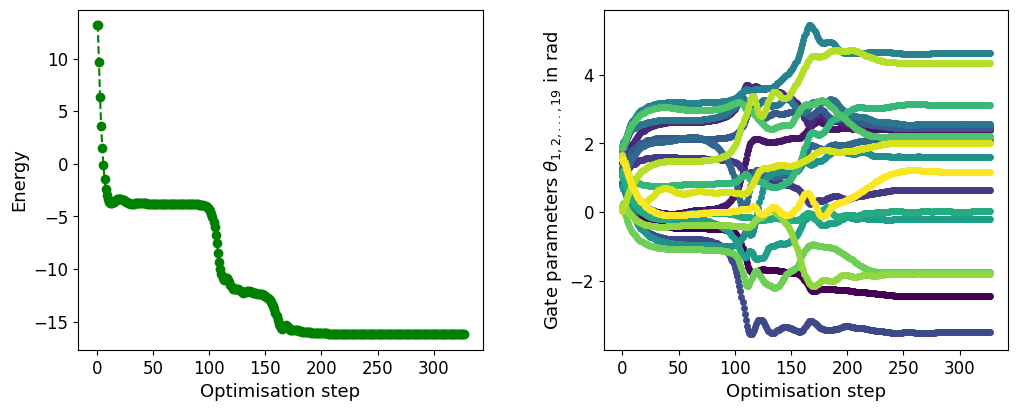

In [31]:
vqe_plot(angle0_full, energy0_full)

## VQE Implementation for First Excited State

In [32]:
gs_theta = angle0[-1]
ground_state = np.real(state_preparation(gs_theta))

In [33]:
@qml.qnode(dev, interface="autograd")
def cost_fn_1(param):
    ansatz(param)
    return qml.expval(H + 10 * qml.Projector(ground_state, wires=range(qubits)))

In [34]:
np.random.seed(1)
theta1 = np.array([2 * np.random.rand() for i in range(n_params)], requires_grad=True)
print(theta1)

[8.34044009e-01 1.44064899e+00 2.28749635e-04 6.04665145e-01
 2.93511782e-01 1.84677190e-01 3.72520423e-01 6.91121454e-01
 7.93534948e-01 1.07763347e+00 8.38389029e-01 1.37043900e+00
 4.08904499e-01 1.75623487e+00 5.47751864e-02 1.34093502e+00
 8.34609605e-01 1.11737966e+00 2.80773877e-01]


In [35]:
with warnings.catch_warnings(action="ignore"):
    # Phase 1: Adam to explore the landscape and find the right basin
    print("Phase 1: Adam")
    opt_adam = qml.AdamOptimizer(stepsize=0.1)
    _, angle_coarse1, energy_coarse1 = run_vqe(theta1, cost_fn_1, opt_adam, max_iterations=1000, print_steps=50)

    # Phase 2: GD from Adam's endpoint to converge cleanly
    print("\nPhase 2: Gradient Descent")
    opt_gd = qml.GradientDescentOptimizer(stepsize=0.01)
    iter1, angle1, energy1 = run_vqe(angle_coarse1[-1], cost_fn_1, opt_gd, max_iterations=1000, print_steps=50)

# Combine both phases for plotting
angle1_full = angle_coarse1 + angle1[1:]
energy1_full = energy_coarse1 + energy1[1:]

Phase 1: Adam
Step = 0,  Energy = 28.43203706
Step = 50,  Energy = -4.14939784
Step = 100,  Energy = -6.67131470
Step = 150,  Energy = -7.12501908
Step = 200,  Energy = -7.66457866
Step = 250,  Energy = -7.83855621
Step = 300,  Energy = -8.57068290
Step = 350,  Energy = -8.59259547
Step = 400,  Energy = -8.59299336
Step = 450,  Energy = -8.59235098
Step = 500,  Energy = -8.59297887
Step = 550,  Energy = -8.59248260
Step = 600,  Energy = -8.59222970
Step = 650,  Energy = -8.59176736
Step = 700,  Energy = -8.58605305
Step = 750,  Energy = -8.58359744
Step = 800,  Energy = -8.59105341
Step = 850,  Energy = -8.59256349
Step = 900,  Energy = -8.59182723
Step = 950,  Energy = -8.59290773

Final value of the ground-state energy = -8.58952813

Optimal value of the circuit parameters = [ 2.45459083e+00  2.47094989e+00 -4.21631226e+00 -1.06289902e-01
  1.07222234e+00 -9.74408441e-02  1.06683374e+00  2.13195598e+00
 -2.48424949e+00 -1.58988947e-03 -1.36714568e+00  2.39921181e+00
  9.95902006e-01 

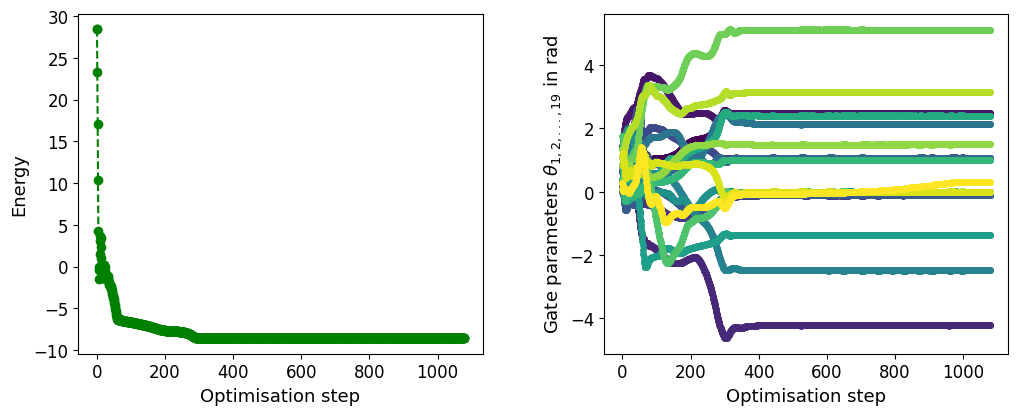

In [36]:
vqe_plot(angle1_full, energy1_full)

## VQE Implementation for Second Excited State

In [37]:
firstes_theta = angle1[-1]
first_excited_state = np.real(state_preparation(firstes_theta))

In [38]:
@qml.qnode(dev, interface="autograd")
def cost_fn_2(param):
    ansatz(param)
    return qml.expval(H 
                      + 30 * qml.Projector(ground_state, wires=range(qubits)) 
                      + 20 * qml.Projector(first_excited_state, wires=range(qubits))
                     )

In [39]:
np.random.seed(2)
theta2 = np.array([2 * np.random.rand() for i in range(n_params)], requires_grad=True)
print(theta2)

[0.8719898  0.05185246 1.09932496 0.87064479 0.8407356  0.66066964
 0.40929727 1.23854193 0.59930935 0.53365455 1.24226767 1.05828419
 0.26915989 1.02715624 0.36887973 1.5706703  1.70795059 0.98847367
 1.69312297]


In [40]:
with warnings.catch_warnings(action="ignore"):
    # Phase 1: Adam to explore the landscape and find the right basin
    print("Phase 1: Adam")
    opt_adam = qml.AdamOptimizer(stepsize=0.1)
    _, angle_coarse2, energy_coarse2 = run_vqe(theta2, cost_fn_2, opt_adam, max_iterations=1000, print_steps=50)

    # Phase 2: GD from Adam's endpoint to converge cleanly
    print("\nPhase 2: Gradient Descent")
    opt_gd = qml.GradientDescentOptimizer(stepsize=0.01)
    iter2, angle2, energy2 = run_vqe(angle_coarse2[-1], cost_fn_2, opt_gd, max_iterations=1000, print_steps=50)

# Combine both phases for plotting
angle2_full = angle_coarse2 + angle2[1:]
energy2_full = energy_coarse2 + energy2[1:]

secondos_theta = angle2[-1]

Phase 1: Adam
Step = 0,  Energy = 21.45080054
Step = 50,  Energy = 8.77671565
Step = 100,  Energy = 7.92460434
Step = 150,  Energy = 4.00934962
Step = 200,  Energy = 3.63019676
Step = 250,  Energy = 3.62029248
Step = 300,  Energy = 3.61690236
Step = 350,  Energy = 3.61767389
Step = 400,  Energy = 3.61559463
Step = 450,  Energy = 3.61604059
Step = 500,  Energy = 3.61661533
Step = 550,  Energy = 3.61553433
Step = 600,  Energy = 3.62080909
Step = 650,  Energy = 3.61557526
Step = 700,  Energy = 3.61612315
Step = 750,  Energy = 3.61622502
Step = 800,  Energy = 3.61637452
Step = 850,  Energy = 3.61585127
Step = 900,  Energy = 3.61565334
Step = 950,  Energy = 3.61602862

Final value of the ground-state energy = 3.61554222

Optimal value of the circuit parameters = [ 3.46159003 -3.50234473  2.07130692 -0.27408271  1.61091576  0.92686542
  4.70779925  0.73927695  2.19480155 -1.58819004  4.61230004  2.45169259
  2.6978797  -1.90345607  0.3877889   1.66053985  4.4993146  -1.79326924
  0.33632718]

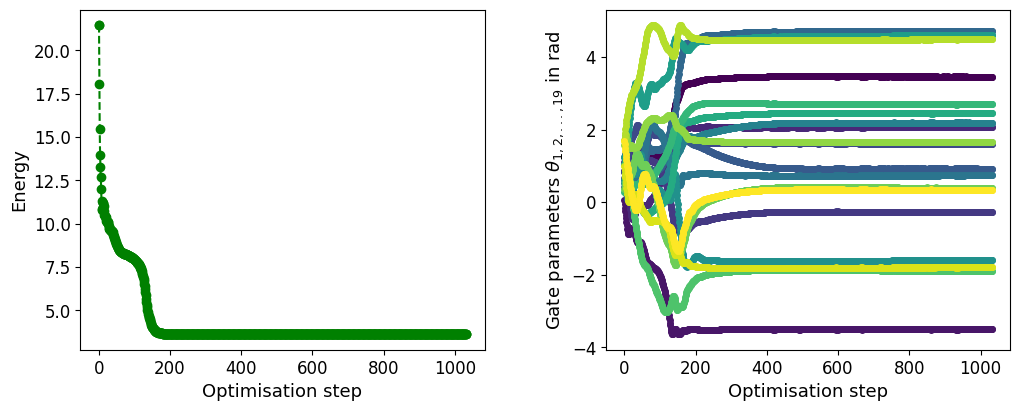

In [41]:
vqe_plot(angle2_full, energy2_full)

## Reachability of exact eigenstates

In [42]:
# Embed exact eigenvectors (18-dim subspace) back into the full 2^qubits Hilbert space
def embed_state(v_col):
    psi = np.zeros(2**qubits)
    psi[sz0_indices] = np.real(v_col)
    return psi

exact_states = [embed_state(v[:, k]) for k in range(3)]

# States found by VQE (real part; imaginary parts are negligible for this real Hamiltonian)
vqe_states = [
    np.real(np.array(state_preparation(gs_theta))),
    np.real(np.array(state_preparation(firstes_theta))),
    np.real(np.array(state_preparation(secondos_theta))),
]
labels = ["GS", "1st ES", "2nd ES"]

# Overlap matrix: rows = exact eigenstates, columns = VQE-found states
# |<exact_k | vqe_j>|^2 close to 1 means VQE converged to that eigenstate
print(f"{'':30s}" + "".join(f"  {lbl:>8s}" for lbl in labels))
for k, ex_st in enumerate(exact_states):
    row = f"exact[{k}] (E = {e[k]:8.4f})      "
    for vqe_st in vqe_states:
        ov = float(np.dot(vqe_st, ex_st) ** 2)
        row += f"  {ov:8.5f}"
    print(row)

                                      GS    1st ES    2nd ES
exact[0] (E = -16.1900)         1.00000   0.00000   0.00000
exact[1] (E =  -8.5930)         0.00000   1.00000   0.00000
exact[2] (E =   3.6155)         0.00000   0.00000   1.00000


In [43]:
from scipy.optimize import minimize as sp_minimize

def max_overlap_sq(target, n_restarts=15):
    """Find max |<ansatz(theta)|target>|^2 over random initial parameters."""
    best = 0.0
    for _ in range(n_restarts):
        theta0 = 2 * np.pi * np.random.rand(n_params)
        res = sp_minimize(
            lambda th: -float(np.dot(np.real(np.array(state_sv(np.array(th)))), target) ** 2),
            theta0,
            method='L-BFGS-B',
            options={'maxiter': 5000, 'ftol': 1e-10},
        )
        if -res.fun > best:
            best = -res.fun
    return best

print("Direct reachability check (max |<ansatz(theta)|exact_k>|^2, 15 random starts each):")
for k, ex_st in enumerate(exact_states):
    ov = max_overlap_sq(ex_st)
    print(f"  exact[{k}] (E = {e[k]:.5f}):  max overlap^2 = {ov:.6f}")

Direct reachability check (max |<ansatz(theta)|exact_k>|^2, 15 random starts each):
  exact[0] (E = -16.18996):  max overlap^2 = 1.000000
  exact[1] (E = -8.59300):  max overlap^2 = 1.000000
  exact[2] (E = 3.61551):  max overlap^2 = 1.000000
